# 06 — Ground Truth Validation
Compare the YOLO-derived heatmap against a heatmap built from the annotated GT head positions.

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
import seaborn as sns

sys.path.insert(0, '..')
from src.heatmap import FLOOR_W, FLOOR_H, SIGMA, FLOOR_POLYGON, make_floor_canvas, project_points, build_heatmap

sns.set_theme(style='whitegrid')

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')

H = np.load(PROCESSED / 'homography.npy')

## Extract GT head positions across all frames

In [5]:
gt = loadmat(RAW / 'mall_gt.mat')

rows = []
for i in range(gt['frame'].shape[1]):
    heads = gt['frame'][0, i][0, 0][0]  # (N, 2) float — (x, y) head positions
    for x, y in heads:
        rows.append({'frame_id': i + 1, 'x': x, 'y': y})

gt_df = pd.DataFrame(rows)
print(f'Total GT head positions: {len(gt_df)} across {gt_df["frame_id"].nunique()} frames')
print(gt_df.head())

Total GT head positions: 62315 across 2000 frames
   frame_id           x          y
0         1  126.779863  60.704778
1         1  116.950512  47.598976
2         1  175.107509  44.322526
3         1  184.117747  45.141638
4         1  192.308874  44.322526


## Calibrate head-to-foot pixel model from YOLO bounding box heights

YOLO bounding box heights from all 2,000 frames give us the person pixel height
at each image y position. A k-NN lookup (k=50) on y gives a smooth, perspective-correct
δ(v) without any binning choices.

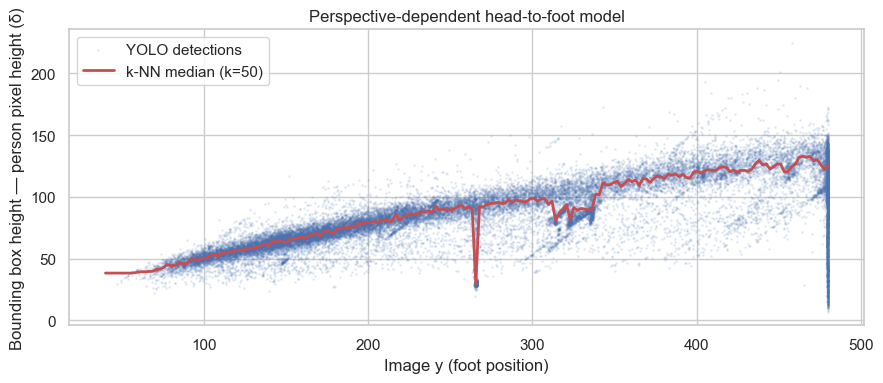

δ at v=380 (near camera): 117 px
δ at v=150 (far):         65 px


In [6]:
from scipy.spatial import cKDTree

bbox_df = pd.read_csv(PROCESSED / '../interim/detections_bbox.csv')

# k-NN on foot y → median bbox height gives δ(v) for any query y
knn_tree = cKDTree(bbox_df[['y']].values)

def delta_fn(v_arr):
    v_arr = np.atleast_1d(v_arr).reshape(-1, 1)
    _, idxs = knn_tree.query(v_arr, k=50)
    return np.median(bbox_df['bbox_h'].values[idxs], axis=1)

v_range = np.linspace(40, 480, 200)
delta_vals = delta_fn(v_range)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(bbox_df['y'], bbox_df['bbox_h'], s=1, alpha=0.1, label='YOLO detections')
ax.plot(v_range, delta_vals, 'r-', lw=2, label='k-NN median (k=50)')
ax.set_xlabel('Image y (foot position)')
ax.set_ylabel('Bounding box height — person pixel height (δ)')
ax.set_title('Perspective-dependent head-to-foot model')
ax.legend()
plt.tight_layout()
plt.show()

print(f'δ at v=380 (near camera): {delta_fn([380])[0]:.0f} px')
print(f'δ at v=150 (far):         {delta_fn([150])[0]:.0f} px')

## Original Homography (5-pt)

### Project GT positions to floor plan

Each GT head at image `(u, v)` is shifted to its estimated foot position `(u, v + δ(v))`
before projecting through H. This makes the correction perspective-correct: δ is larger
for near people and smaller for distant ones, matching how perspective compression works.

In [7]:
pts_img = gt_df[['x', 'y']].values.copy()
pts_img[:, 1] = pts_img[:, 1] + delta_fn(pts_img[:, 1])  # shift head → estimated foot

proj = project_points(pts_img, H)

gt_df['px'] = proj[:, 0]
gt_df['py'] = proj[:, 1]

in_bounds = gt_df['px'].between(0, FLOOR_W) & gt_df['py'].between(0, FLOOR_H)
gt_proj = gt_df[in_bounds].copy()

print(f'In-bounds: {len(gt_proj)} / {len(gt_df)} ({in_bounds.mean()*100:.1f}%)')

In-bounds: 60669 / 62315 (97.4%)


### Build GT and YOLO heatmaps

In [8]:
yolo_proj = pd.read_csv(PROCESSED / 'projected_detections.csv')

heatmap_gt   = build_heatmap(gt_proj, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])
heatmap_yolo = build_heatmap(yolo_proj, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])

print(f'GT   heatmap shape: {heatmap_gt.shape}')
print(f'YOLO heatmap shape: {heatmap_yolo.shape}')

GT   heatmap shape: (1200, 820)
YOLO heatmap shape: (1200, 820)


### Side-by-side comparison

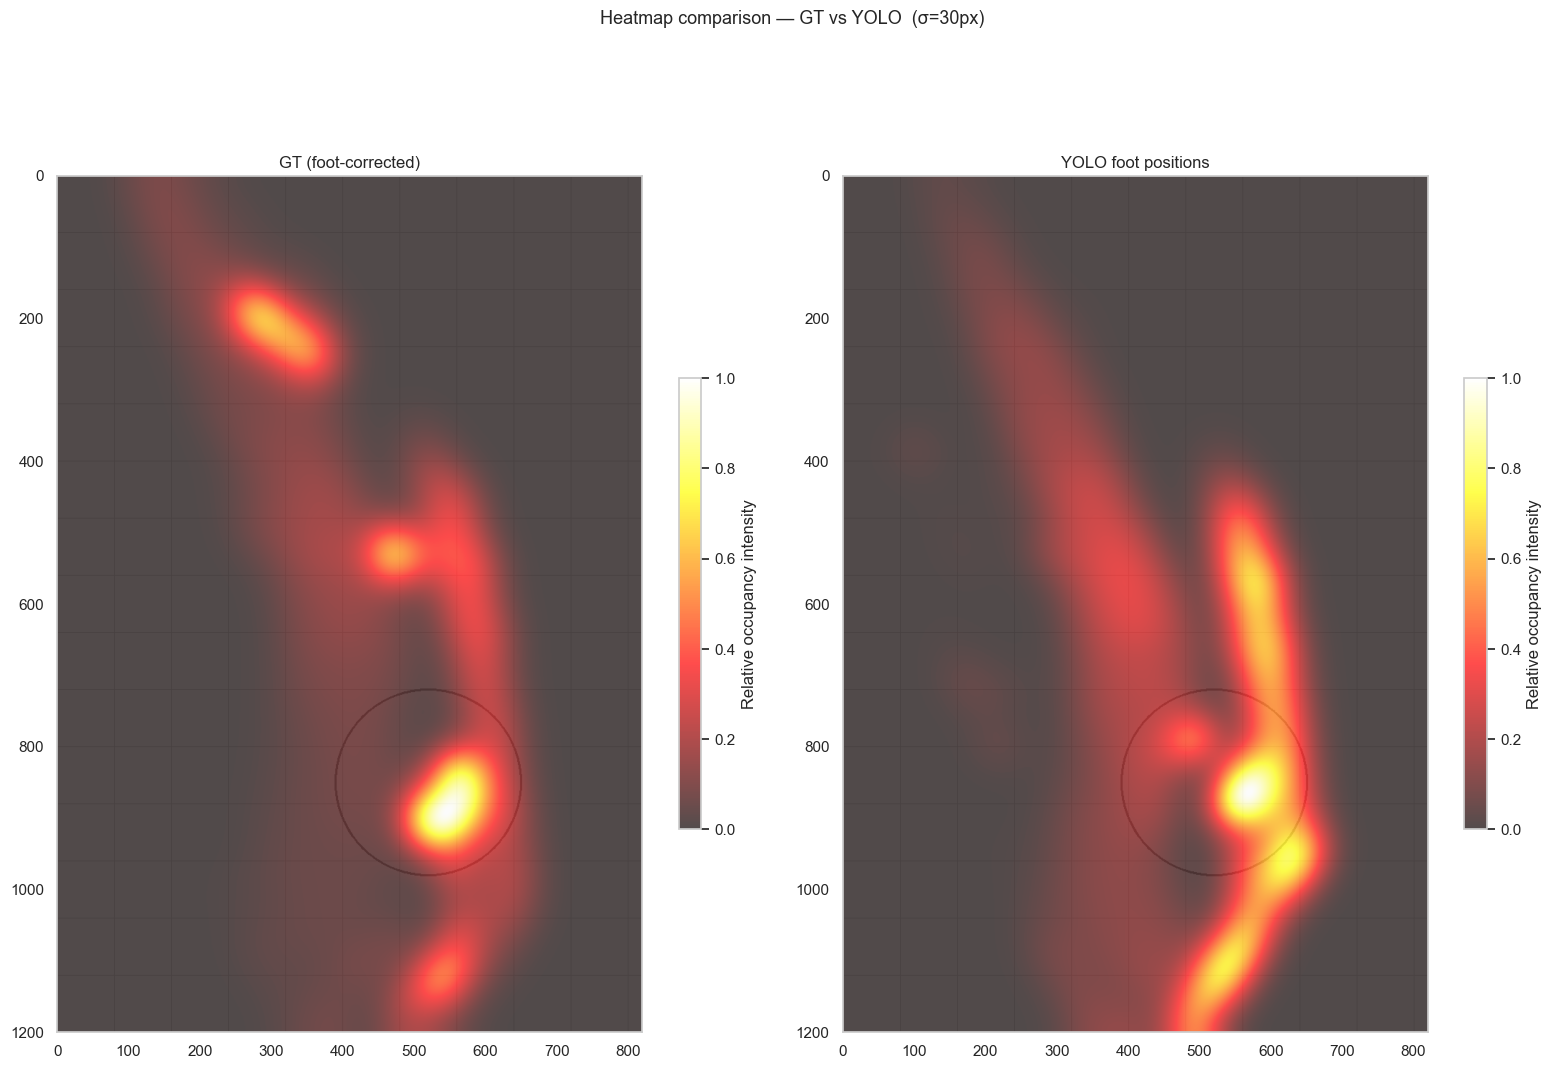

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

titles = ['GT (foot-corrected)', 'YOLO foot positions']
heatmaps = [heatmap_gt, heatmap_yolo]

for ax, hm, title in zip(axes, heatmaps, titles):
    ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = ax.imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0],
                   cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Relative occupancy intensity', shrink=0.4)
    ax.grid(False)
    ax.set_title(title, fontsize=12)

plt.suptitle(f'Heatmap comparison — GT vs YOLO  (σ={SIGMA}px)', fontsize=13)
plt.tight_layout()
plt.show()

### Pixel-level difference map

Signed difference `YOLO − GT`. Positive (warm) = YOLO detects more;
negative (cool) = YOLO misses relative to GT.

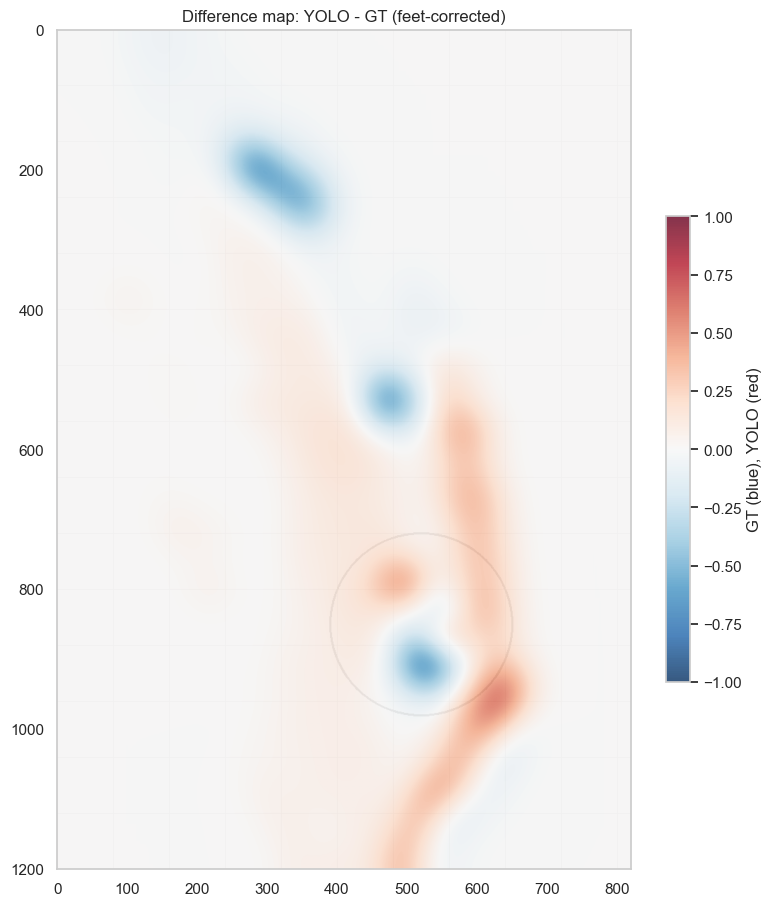

Mean absolute difference: 0.0479
Max over-detection:  0.5642   Max under-detection: -0.5637


In [10]:
diff = heatmap_yolo - heatmap_gt

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
im = ax.imshow(diff, extent=[0, FLOOR_W, FLOOR_H, 0],
               cmap='RdBu_r', alpha=0.8,
               vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='GT (blue), YOLO (red)', shrink=0.4)
ax.grid(False)
ax.set_title('Difference map: YOLO - GT (feet-corrected)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Mean absolute difference: {np.abs(diff).mean():.4f}')
print(f'Max over-detection:  {diff.max():.4f}   Max under-detection: {diff.min():.4f}')

## New Homography (10-pt)

In-bounds: 60722 / 62315 (97.4%)


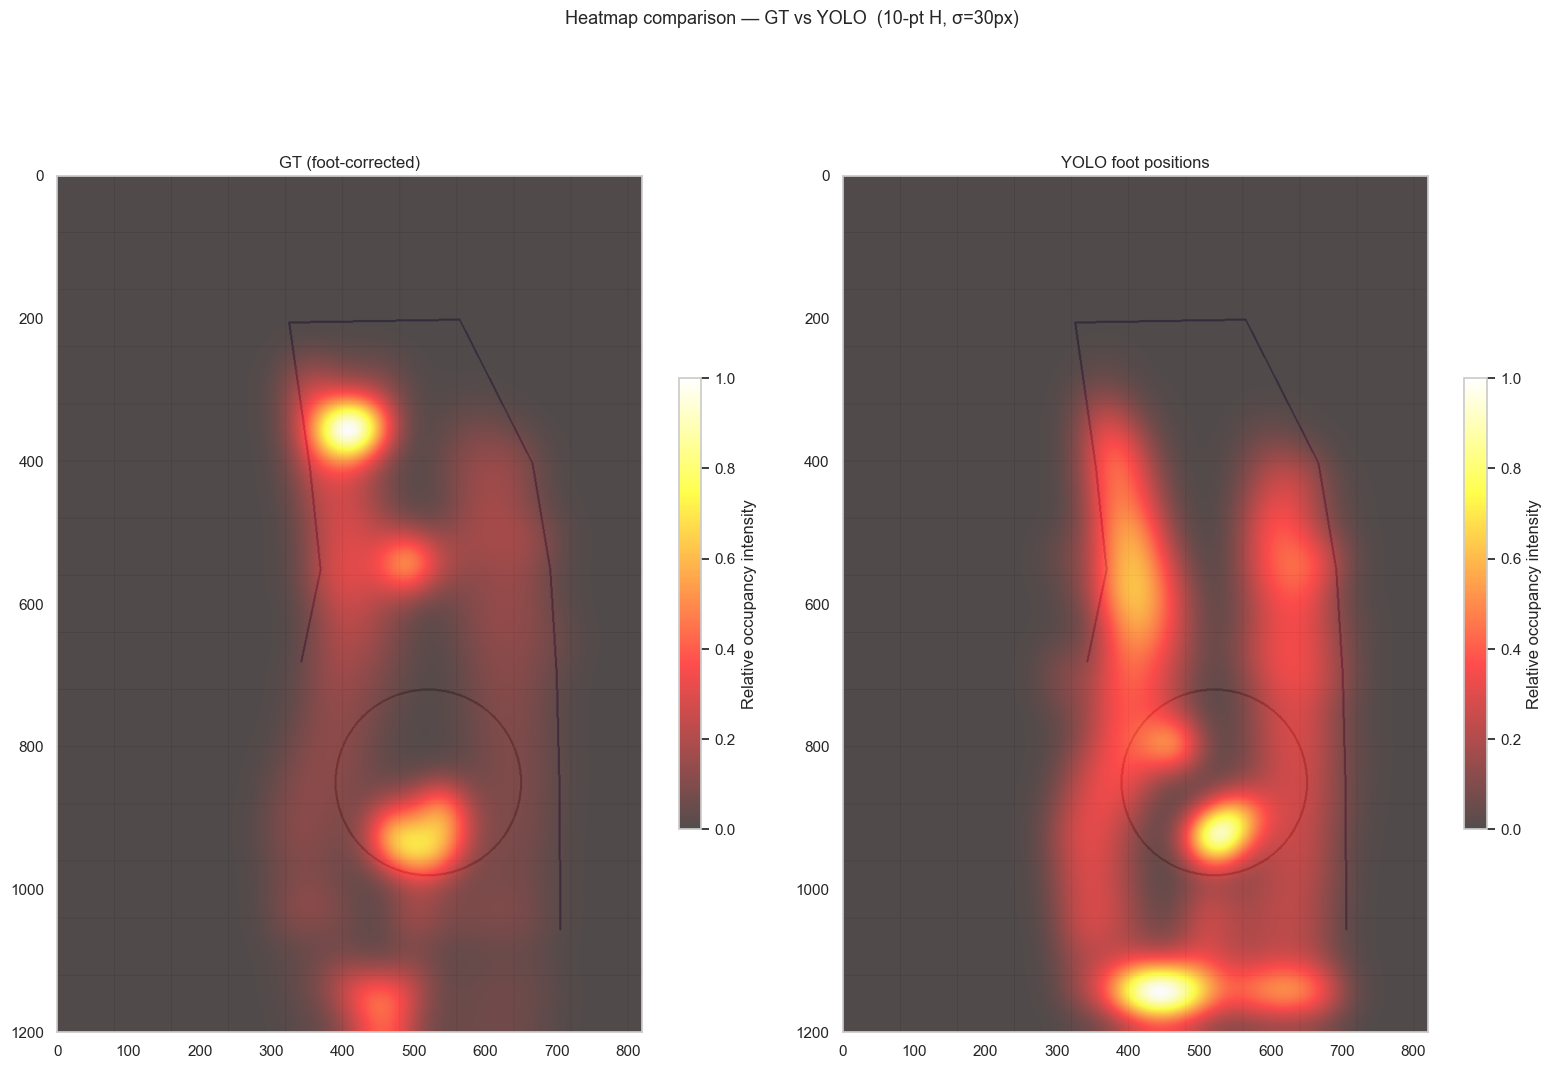

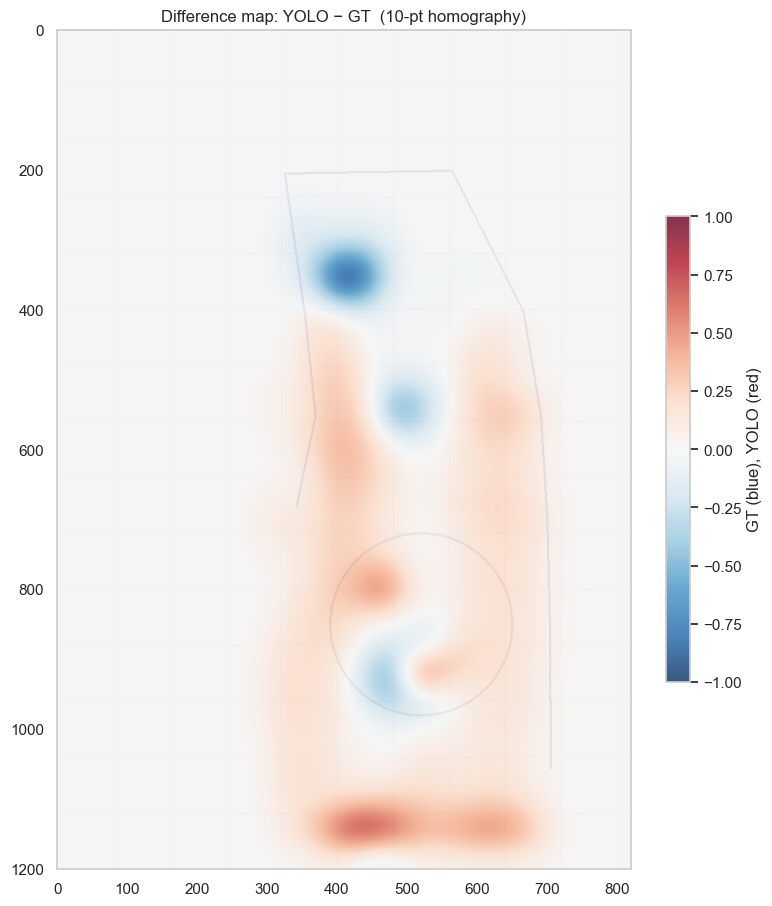

Mean absolute difference: 0.0582
Max over-detection:  0.6317   Max under-detection: -0.8269


In [11]:
H_new = np.load(PROCESSED / 'homography_10pt.npy')

pts_img_new = gt_df[['x', 'y']].values.copy()
pts_img_new[:, 1] = pts_img_new[:, 1] + delta_fn(pts_img_new[:, 1])
proj_new = project_points(pts_img_new, H_new)

gt_df_new = gt_df.copy()
gt_df_new['px'] = proj_new[:, 0]
gt_df_new['py'] = proj_new[:, 1]
in_bounds_new = gt_df_new['px'].between(0, FLOOR_W) & gt_df_new['py'].between(0, FLOOR_H)
gt_proj_new = gt_df_new[in_bounds_new].copy()
print(f'In-bounds: {len(gt_proj_new)} / {len(gt_df_new)} ({in_bounds_new.mean()*100:.1f}%)')

yolo_proj_10pt = pd.read_csv(PROCESSED / 'projected_detections_10pt.csv')

heatmap_gt_10pt   = build_heatmap(gt_proj_new, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])
heatmap_yolo_10pt = build_heatmap(yolo_proj_10pt, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])

fig, axes = plt.subplots(1, 2, figsize=(16, 12))
for ax, hm, title in zip(axes, [heatmap_gt_10pt, heatmap_yolo_10pt],
                          ['GT (foot-corrected)', 'YOLO foot positions']):
    ax.imshow(make_floor_canvas(polygon_pts=FLOOR_POLYGON), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = ax.imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0], cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Relative occupancy intensity', shrink=0.4)
    ax.grid(False)
    ax.set_title(title, fontsize=12)
plt.suptitle(f'Heatmap comparison — GT vs YOLO  (10-pt H, σ={SIGMA}px)', fontsize=13)
plt.tight_layout()
plt.show()

diff_10pt = heatmap_yolo_10pt - heatmap_gt_10pt
fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(make_floor_canvas(polygon_pts=FLOOR_POLYGON), extent=[0, FLOOR_W, FLOOR_H, 0])
im = ax.imshow(diff_10pt, extent=[0, FLOOR_W, FLOOR_H, 0],
               cmap='RdBu_r', alpha=0.8, vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='GT (blue), YOLO (red)', shrink=0.4)
ax.grid(False)
ax.set_title('Difference map: YOLO − GT  (10-pt homography)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Mean absolute difference: {np.abs(diff_10pt).mean():.4f}')
print(f'Max over-detection:  {diff_10pt.max():.4f}   Max under-detection: {diff_10pt.min():.4f}')

## Validating the model-reliability overlay (Phase 11)

The web app shades "low-reliability" zones using detection **confidence** as a proxy for
where the model under-detects. That proxy is only honest if confidence actually collapses
where recall collapses — otherwise survivorship bias (the model confidently catching the
few easy people in a blind zone) would hide the very dead zones we want to flag.

Here we check it in **camera space** against GT: bin both GT heads and YOLO detections into
vertical bands and compare counts vs mean confidence. (GT = heads, detections = feet, so
per-band recall is offset-distorted, but the trends are robust.)

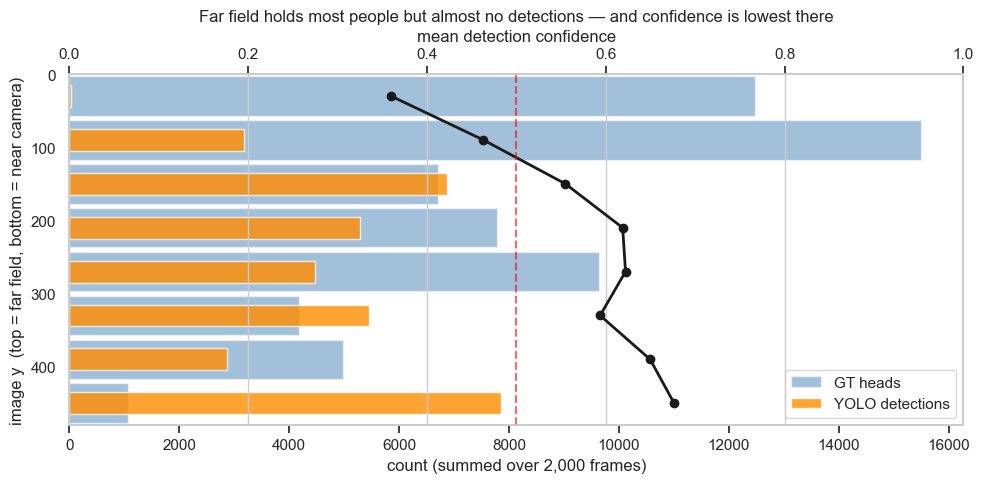

 band    gt  det  mean_conf
    0 12471   22   0.359909
    1 15491 3170   0.463179
    2  6706 6870   0.554918
    3  7788 5297   0.618889
    4  9640 4471   0.622136
    5  4184 5459   0.593673
    6  4974 2875   0.649600
    7  1061 7850   0.676479

Far field (top quarter): 27,962 GT heads (45% of all people) but only 3,192 detections, mean conf 0.41.


In [12]:
from src.heatmap import CAM_H, CAM_W, compute_confidence_cutoff, build_reliability_mask

det = pd.read_csv(PROCESSED / '../interim/detections.csv')   # camera-space x, y, confidence

# --- Per-band GT count, detection count, mean confidence ---
N_BANDS = 8
band_h = CAM_H / N_BANDS
gt_band = (gt_df['y'].clip(0, CAM_H - 1) / band_h).astype(int)
det_band = (det['y'].clip(0, CAM_H - 1) / band_h).astype(int)

bands = pd.DataFrame({'band': range(N_BANDS)})
bands['y_centre'] = (bands['band'] + 0.5) * band_h
bands['gt'] = gt_band.value_counts().reindex(bands['band'], fill_value=0).values
bands['det'] = det_band.value_counts().reindex(bands['band'], fill_value=0).values
bands['mean_conf'] = det.groupby(det_band)['confidence'].mean().reindex(bands['band']).values

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.barh(bands['y_centre'], bands['gt'], height=band_h * 0.9, color='steelblue', alpha=0.5, label='GT heads')
ax1.barh(bands['y_centre'], bands['det'], height=band_h * 0.5, color='darkorange', alpha=0.8, label='YOLO detections')
ax1.set_ylim(CAM_H, 0)  # image coords: 0 at top (far field), 480 at bottom (near camera)
ax1.set_xlabel('count (summed over 2,000 frames)')
ax1.set_ylabel('image y  (top = far field, bottom = near camera)')
ax1.legend(loc='lower right')
ax1.grid(False)

ax2 = ax1.twiny()
ax2.plot(bands['mean_conf'], bands['y_centre'], 'k-o', lw=2, label='mean confidence')
ax2.set_xlim(0, 1)
ax2.set_xlabel('mean detection confidence')
ax2.axvline(0.5, color='red', ls='--', alpha=0.6)
plt.title('Far field holds most people but almost no detections — and confidence is lowest there')
plt.tight_layout()
plt.show()

print(bands[['band', 'gt', 'det', 'mean_conf']].to_string(index=False))
far = bands[bands['y_centre'] < CAM_H / 4]
print(f"\nFar field (top quarter): {far['gt'].sum():,} GT heads "
      f"({100 * far['gt'].sum() / bands['gt'].sum():.0f}% of all people) "
      f"but only {far['det'].sum():,} detections, mean conf {far['mean_conf'].mean():.2f}.")

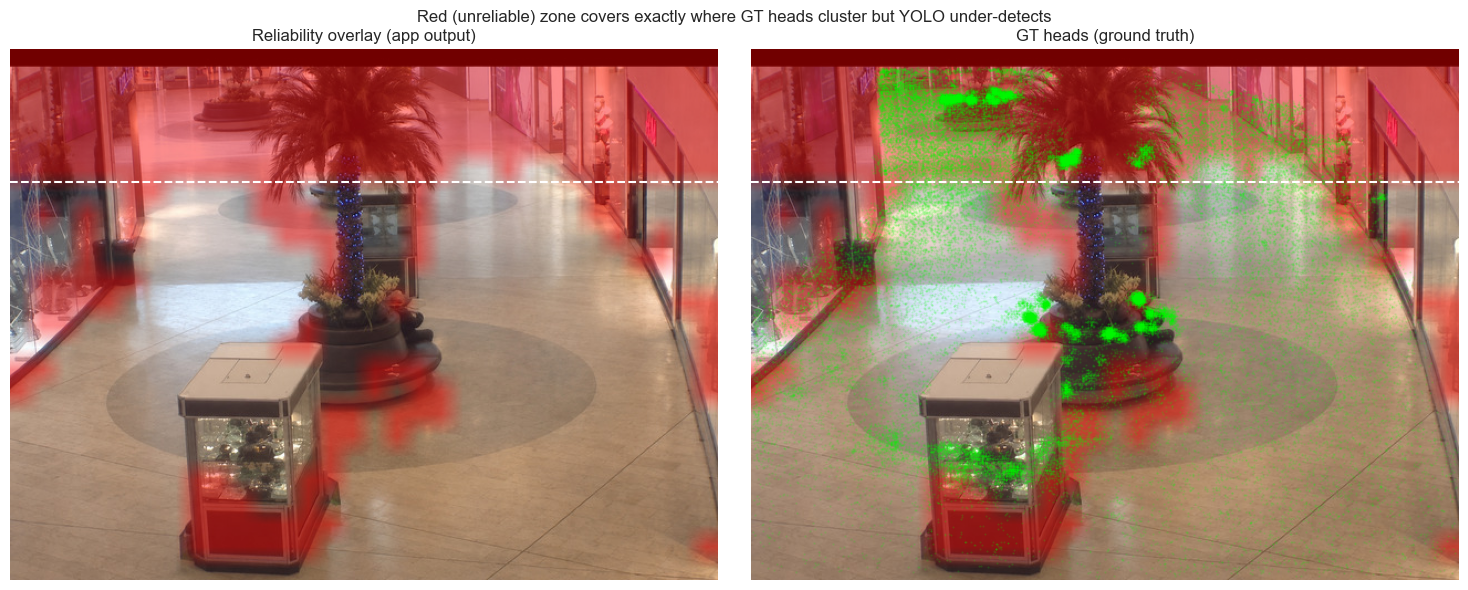

Confidence frontier at y=120px; 36% of cells flagged unreliable.


In [13]:
# --- The overlay the web app renders, validated against GT ---
# build_reliability_mask flags cells as unreliable when detections are weak OR when
# they are sparse above the confidence frontier (the far-field blind zone).
mask = build_reliability_mask(det, threshold=0.5)
cutoff_y = compute_confidence_cutoff(det, threshold=0.5)

bg = plt.imread('../reports/figures/Empty_frame_85.jpg')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, show_gt, title in zip(axes, [False, True],
                              ['Reliability overlay (app output)', 'GT heads (ground truth)']):
    ax.imshow(bg, extent=[0, CAM_W, CAM_H, 0])
    rgba = np.zeros((*mask.shape, 4)); rgba[..., 0] = 1.0; rgba[..., 3] = mask * 0.45
    ax.imshow(rgba, extent=[0, CAM_W, CAM_H, 0], interpolation='bilinear')
    if show_gt:
        ax.scatter(gt_df['x'], gt_df['y'], s=0.3, c='lime', alpha=0.15)
    ax.axhline(cutoff_y, color='white', ls='--', lw=1.5)
    ax.set_title(title); ax.axis('off')
plt.suptitle('Red (unreliable) zone covers exactly where GT heads cluster but YOLO under-detects', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Confidence frontier at y={cutoff_y}px; {100 * (mask > 0).mean():.0f}% of cells flagged unreliable.')